# Stock Price Prediction using Machine Learning

## Objective

The objective of this project is to predict the closing stock price using historical stock market data and Linear Regression.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
df = pd.read_csv("/Tesla.csv")

In [27]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-06-29,1.5926669836044312,1.6666669845581055,1.1693329811096191,1.2666670083999634,281494500
3,2010-06-30,1.5886670351028442,2.0280001163482666,1.553333044052124,1.7193330526351929,257806500
4,2010-07-01,1.4639999866485596,1.7280000448226929,1.3513330221176147,1.6666669845581055,123282000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   3694 non-null   object
 1   Close   3693 non-null   object
 2   High    3693 non-null   object
 3   Low     3693 non-null   object
 4   Open    3693 non-null   object
 5   Volume  3693 non-null   object
dtypes: object(6)
memory usage: 173.3+ KB


In [29]:
df.isnull().sum()

,0
Price,0
Close,1
High,1
Low,1
Open,1
Volume,1


In [30]:
df.dropna(inplace=True)

In [31]:
import pandas as pd

# Read the dataset
df = pd.read_csv("/Tesla.csv")

# Remove the first row (Ticker)
df = df.iloc[1:].reset_index(drop=True)

# Rename 'Price' column to 'Date'
df.rename(columns={"Price": "Date"}, inplace=True)

# Remove rows where Date is missing
df = df[df["Date"].notna()]

# Remove the row containing the text "Date"
df = df[df["Date"] != "Date"]

# Convert data types
df["Date"] = pd.to_datetime(df["Date"])

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])

df.head()

,Date,Close,High,Low,Open,Volume
1,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
3,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
4,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
5,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3692 entries, 1 to 3692
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3692 non-null   datetime64[ns]
 1   Close   3692 non-null   float64       
 2   High    3692 non-null   float64       
 3   Low     3692 non-null   float64       
 4   Open    3692 non-null   float64       
 5   Volume  3692 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 201.9 KB


In [33]:
X = df[["Open", "High", "Low", "Volume"]]

y = df["Close"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 0.8102790223069091
Mean Squared Error (MSE): 3.529351893021258
R² Score: 0.9997013014278784


In [38]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,1.784000,1.792262
1,221.100006,223.352498
2,1.876000,1.869946
3,16.145332,16.396463
4,12.726667,12.680402
5,294.363342,293.073375
6,1.836000,1.859176
7,21.417334,21.378039
8,13.361333,13.434936
9,16.704000,17.042300


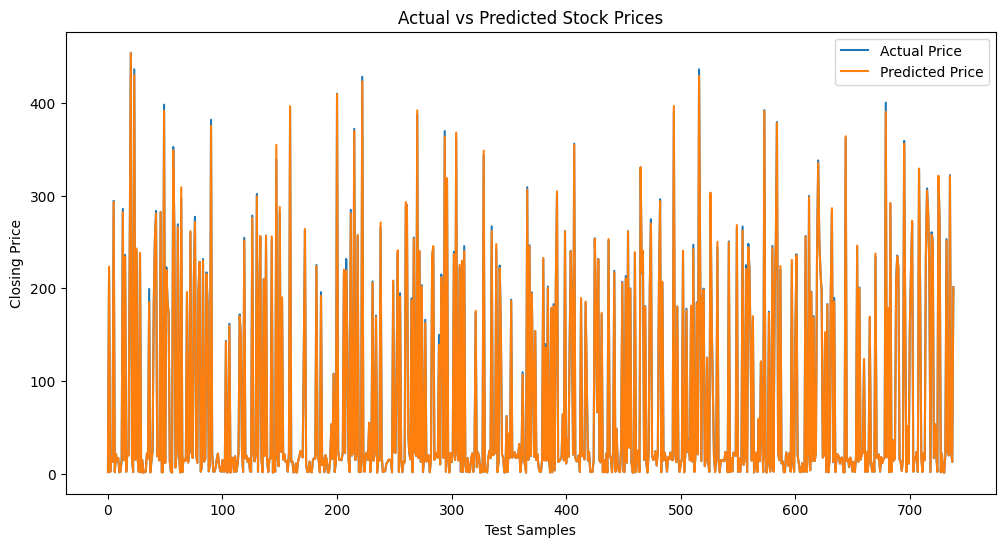

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Test Samples")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

# Conclusion

A Linear Regression model was developed to predict Tesla stock closing prices using historical stock market data. The model was trained using the Open, High, Low, and Volume features. The model's performance was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The comparison between actual and predicted prices demonstrates the model's effectiveness in estimating stock closing prices based on historical market information.